In [8]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

# ====================================================
# 1. Global config
# ====================================================

from pathlib import Path
import shutil

source_root = Path("/data/users/zhouz6436/Pneumonia_image_classification/chest_xray")
target_root = Path("/data/users/zhouz6436/Pneumonia_image_classification/chest_xray_3class")

image_extensions = {
    ".jpeg", ".jpg", ".png", ".bmp"
}

for split in ["train", "test"]:
    normal_source = source_root / split / "NORMAL"
    pneumonia_source = source_root / split / "PNEUMONIA"

    normal_target = target_root / split / "NORMAL"
    bacteria_target = target_root / split / "bacteria"
    virus_target = target_root / split / "virus"

    for folder in [
        normal_target,
        bacteria_target,
        virus_target
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    normal_copied = 0
    bacteria_copied = 0
    virus_copied = 0
    unrecognized = []

    for image_path in normal_source.rglob("*"):
        if (
            image_path.is_file()
            and image_path.suffix.casefold() in image_extensions
        ):
            shutil.copy2(
                image_path,
                normal_target / image_path.name
            )
            normal_copied += 1

    for image_path in pneumonia_source.rglob("*"):
        if (
            not image_path.is_file()
            or image_path.suffix.casefold()
            not in image_extensions
        ):
            continue

        filename = image_path.name.casefold()

        if "bacteria" in filename:
            shutil.copy2(
                image_path,
                bacteria_target / image_path.name
            )
            bacteria_copied += 1

        elif "virus" in filename:
            shutil.copy2(
                image_path,
                virus_target / image_path.name
            )
            virus_copied += 1

        else:
            unrecognized.append(image_path.name)

    print(f"\n{split}:")
    print("NORMAL copied:", normal_copied)
    print("bacteria copied:", bacteria_copied)
    print("virus copied:", virus_copied)
    print("unrecognized:", len(unrecognized))

    if unrecognized:
        print("Examples:", unrecognized[:10])


train:
NORMAL copied: 1349
bacteria copied: 2538
virus copied: 1345
unrecognized: 0

test:
NORMAL copied: 234
bacteria copied: 242
virus copied: 148
unrecognized: 0


In [2]:
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 25.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.5 MB/s eta 0:00:00ta 0:00:01


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123
root_dir = Path("/data/users/zhouz6436/Pneumonia_image_classification/chest_xray_3class")

train_dir = root_dir / "train"
test_dir = root_dir / "test"

AUTOTUNE = tf.data.AUTOTUNE

In [10]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [11]:

# Unbatched train set for manual train/val split
train_ds_raw = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_ds_raw = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    batch_size=None,
)

class_names = train_ds_raw.class_names
test_class_names = test_ds_raw.class_names
num_classes = len(class_names)

print("Training classes:", class_names)
print("Test classes:", test_class_names)
print("Number of classes:", num_classes)

expected_classes = {
    "NORMAL",
    "bacteria",
    "virus"
}

assert num_classes == 3, (
    f"Expected 3 classes, found "
    f"{num_classes}: {class_names}"
)

assert set(class_names) == expected_classes, (
    f"Unexpected training classes: {class_names}"
)

assert test_class_names == class_names, (
    "Training and test class orders do not match: "
    f"{class_names} versus {test_class_names}"
)

Found 5232 files belonging to 3 classes.
Found 624 files belonging to 3 classes.
Training classes: ['NORMAL', 'bacteria', 'virus']
Test classes: ['NORMAL', 'bacteria', 'virus']
Number of classes: 3


E0000 00:00:1786697392.109035  654760 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
# Total number of training images
total = train_ds_raw.cardinality().numpy()

# Use 10% of the original training directory as validation data
val_size = int(0.10 * total)
train_size = total - val_size

print("Total images:", total)
print("Training images:", train_size)
print("Validation images:", val_size)

train_ds_unbatched = train_ds_raw.take(train_size)
val_ds_unbatched = train_ds_raw.skip(train_size)

total_train = train_ds_unbatched.cardinality().numpy()

def make_subset(fraction):
    n = max(1, int(total_train * fraction))

    subset_raw = train_ds_unbatched.take(n)

    print(
        f"{int(fraction * 100)}% subset:",
        n,
        "images"
    )

    return prepare(
        subset_raw,
        shuffle=True
    )

train_10 = make_subset(0.10)
train_25 = make_subset(0.25)
train_50 = make_subset(0.50)

train_100 = prepare(
    train_ds_unbatched,
    shuffle=True
)

val = prepare(
    val_ds_unbatched,
    shuffle=False
)

test = prepare(
    test_ds_raw,
    shuffle=False
)

for images, labels in test.take(1):
    print("Test image shape:", images.shape)
    print("Test label shape:", labels.shape)
    print("Labels in first test batch:", labels.numpy())


Total images: 5232
Training images: 4709
Validation images: 523
10% subset: 470 images
25% subset: 1177 images
50% subset: 2354 images
Test image shape: (32, 224, 224, 3)
Test label shape: (32,)
Labels in first test batch: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
# ====================================================
# 5. Shared model definition: MobileNetV2 from scratch
# ====================================================
def make_backbone():
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=None,
        pooling="avg",
    )

def make_classifier():
    backbone = make_backbone()

    inputs = tf.keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    x = backbone(inputs)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

model = make_classifier()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 2,227,715 (8.50 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [14]:
from collections import OrderedDict

# ====================================================
# Train 3‑class Model (NORMAL / bacteria / virus)
# ====================================================
EPOCHS = 20

subsets = OrderedDict({
    "10%": train_10,
    "25%": train_25,
    "50%": train_50,
    "100%": train_100,
})

histories = {}
tests = {}
models_3 = OrderedDict()

for name, subset_ds in subsets.items():
    print(
        f"\n=== Model A three-class training: "
        f"{name} subset ==="
    )

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = make_classifier()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        subset_ds,
        epochs=EPOCHS,
        validation_data=val,
        callbacks=callbacks,
        verbose=1
    )

    test_metrics = model.evaluate(
        test,
        return_dict=True,
        verbose=1
    )

    histories[name] = history.history
    tests[name] = test_metrics
    models_3[name] = model

print("\nThree-class test results:")

for name, metrics in tests.items():
    print(name, metrics)


=== Model A three-class training: 10% subset ===
Epoch 1/20


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6298 - loss: 0.8937 - val_accuracy: 0.5201 - val_loss: 1.0827
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6064 - loss: 0.9186 - val_accuracy: 0.4952 - val_loss: 1.0807
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7191 - loss: 0.6789 - val_accuracy: 0.4780 - val_loss: 1.0757
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7319 - loss: 0.6891 - val_accuracy: 0.5048 - val_loss: 1.0700
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7532 - loss: 0.5428 - val_accuracy: 0.4723 - val_loss: 1.0692
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7723 - loss: 0.5027 - val_accuracy: 0.5086 - val_loss: 1.0532
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7660 - loss: 0.6092 - val_accuracy: 0.5029 - val_loss: 1.0690
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7255 - loss: 0.5985 - val_accuracy: 0.4837 - val_loss: 1.1139
Epo

In [17]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.6 MB/s eta 0:00:00


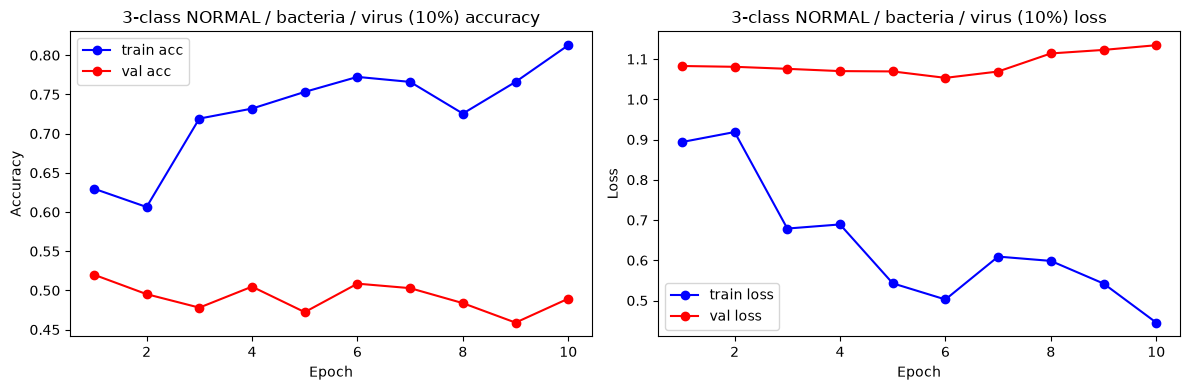

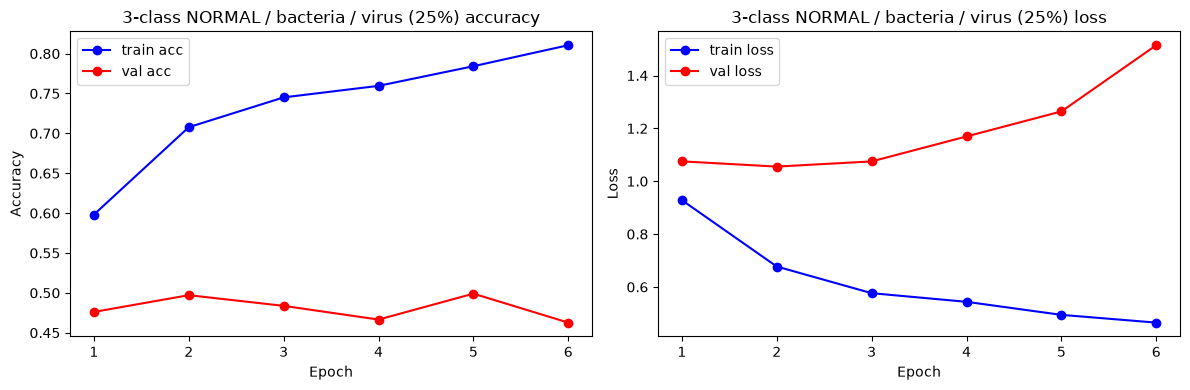

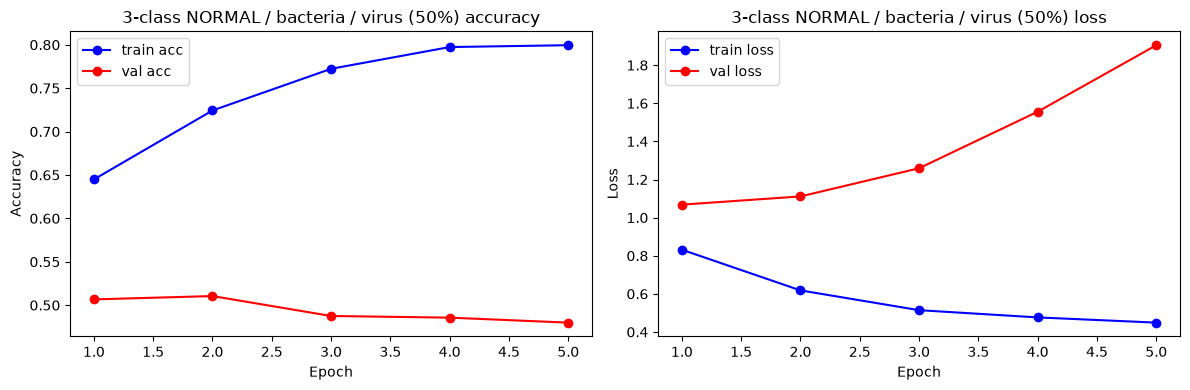

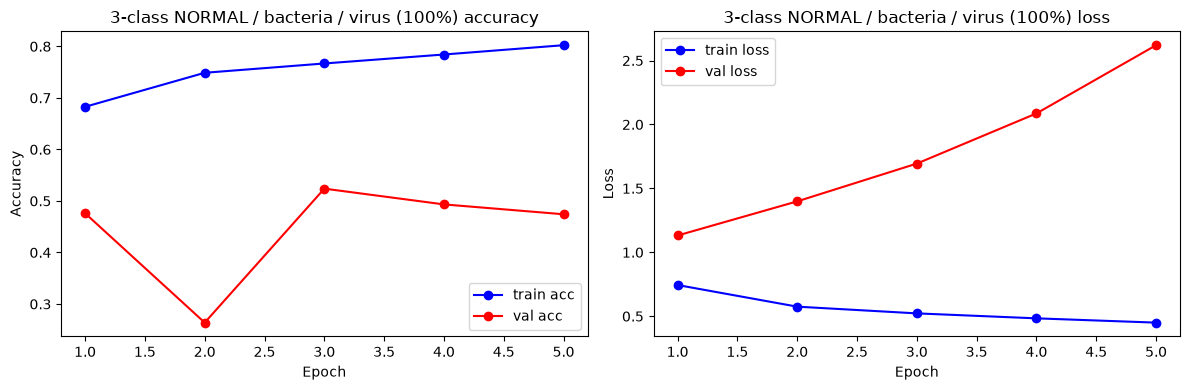

In [18]:
import matplotlib.pyplot as plt

# ====================================================
# Plot histories for all 3‑class subsets
# ====================================================
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if len(acc) > 0:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if len(val_acc) > 0:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if len(loss) > 0:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if len(val_loss) > 0:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# plot all 3‑class subset runs
for frac, hist_dict in histories.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"3‑class NORMAL / bacteria / virus ({frac})"
    )


In [22]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 29.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 61.2 MB/s eta 0:00:00:00:0100:01


In [23]:
# true labels (from raw test dataset)
# true labels (from raw test dataset)
y_true_batches = []
for _, labels in test_ds_raw:
    y_true_batches.append(labels.numpy().ravel()) 

y_true = np.concatenate(y_true_batches, axis=0)
class_names = train_ds_raw.class_names  # ['NORMAL', 'bacteria', 'virus']

from sklearn.metrics import classification_report, confusion_matrix

for name, model in models_3.items():
    print(f"\n=== Evaluation on test set – {name} subset ===")
    # predicted probabilities on batched `test`
    probs = model.predict(test)
    y_pred = probs.argmax(axis=1)

    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))



=== Evaluation on test set – 10% subset ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
    bacteria       0.39      1.00      0.56       242
       virus       0.00      0.00      0.00       148

    accuracy                           0.39       624
   macro avg       0.13      0.33      0.19       624
weighted avg       0.15      0.39      0.22       624

Confusion matrix:
[[  0 234   0]
 [  0 242   0]
 [  0 148   0]]

=== Evaluation on test set – 25% subset ===


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
    bacteria       0.39      1.00      0.56       242
       virus       0.00      0.00      0.00       148

    accuracy                           0.39       624
   macro avg       0.13      0.33      0.19       624
weighted avg       0.15      0.39      0.22       624

Confusion matrix:
[[  0 234   0]
 [  0 242   0]
 [  0 148   0]]

=== Evaluation on test set – 50% subset ===


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
    bacteria       0.39      1.00      0.56       242
       virus       0.00      0.00      0.00       148

    accuracy                           0.39       624
   macro avg       0.13      0.33      0.19       624
weighted avg       0.15      0.39      0.22       624

Confusion matrix:
[[  0 234   0]
 [  0 242   0]
 [  0 148   0]]

=== Evaluation on test set – 100% subset ===


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
    bacteria       0.39      1.00      0.56       242
       virus       0.00      0.00      0.00       148

    accuracy                           0.39       624
   macro avg       0.13      0.33      0.19       624
weighted avg       0.15      0.39      0.22       624

Confusion matrix:
[[  0 234   0]
 [  0 242   0]
 [  0 148   0]]


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital